# Spotify Decoded — Machine Learning

Two questions drive this notebook. First: can I predict whether I will skip a track, using only the context around a play — the time, the platform, how many times I have heard the song before? Second: do my listening habits cluster into meaningful groups when looked at through the lens of artist engagement rather than genre labels?

No audio features from the Spotify API are used here. Everything is derived from the streaming history alone.


In [1]:
import sys
sys.path.append("../src")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score,
                              RocCurveDisplay, ConfusionMatrixDisplay)

from spotify_parser import load_all

df_tracks, _ = load_all("../data/raw/")

df_tracks["hour"]      = df_tracks["ts_local"].dt.hour
df_tracks["dow"]       = df_tracks["ts_local"].dt.dayofweek
df_tracks["year"]      = df_tracks["ts_local"].dt.year
df_tracks["minutes"]   = df_tracks["ms_played"] / 60_000
df_tracks["completed"] = df_tracks["reason_end"] == "trackdone"
df_tracks["skipped"]   = df_tracks["skipped"].fillna(False).astype(bool)

def norm_platform(p):
    if not isinstance(p, str): return "Other"
    p = p.lower()
    if "android" in p: return "Android"
    if "windows" in p: return "Windows"
    if "osx" in p or "mac" in p: return "macOS"
    return "Other"

df_tracks["platform_clean"] = df_tracks["platform"].apply(norm_platform)

PALETTE = {
    "primary": "#1DB954",
    "accent":  "#FF6B6B",
    "muted":   "#B3B3B3",
    "dark":    "#191414",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "grid.linestyle":   "--",
    "font.family":      "sans-serif",
    "figure.dpi":       150,
})

Path("../models").mkdir(exist_ok=True)
print(f"Loaded {len(df_tracks):,} tracks")


Loaded 80,623 raw records from 9 files
  → 80,512 music tracks
  → 111 podcast plays
  → Date range: 2020-10-31 → 2026-04-02
  → Total listening: 2728.7 hours
Loaded 80,512 tracks


Skip predictor

 Why 2022 onwards only

The skip field exists across the full dataset, but the EDA showed it was not reliably recorded before 2022. Using pre-2022 data would introduce systematic noise into the labels.


In [2]:
model_data = df_tracks[df_tracks["year"] >= 2022].copy().sort_values("ts")

print(f"Records for modelling: {len(model_data):,}")
print(f"Skip rate in this subset: {model_data['skipped'].mean()*100:.1f}%")
print(f"Years covered: {sorted(model_data['year'].unique())}")


Records for modelling: 70,276
Skip rate in this subset: 35.5%
Years covered: [np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]


35.5% of plays are skips. That is a healthy class balance — no resampling needed.


## 2. Feature engineering

The Spotify API would give audio features like valence and energy, but I want to see how far pure behavioural features get. Everything below is derived from the streaming history alone.


In [3]:
t = model_data.copy()


t["hour_sin"]  = np.sin(2 * np.pi * t["hour"] / 24)
t["hour_cos"]  = np.cos(2 * np.pi * t["hour"] / 24)
t["dow_sin"]   = np.sin(2 * np.pi * t["dow"] / 7)
t["dow_cos"]   = np.cos(2 * np.pi * t["dow"] / 7)


t["is_shuffle"]        = t["shuffle"].astype(int)
t["is_offline"]        = t["offline"].fillna(False).astype(int)
t["is_morning"]        = ((t["hour"] >= 6) & (t["hour"] <= 11)).astype(int)
t["is_late_night"]     = (t["hour"] <= 5).astype(int)
t["platform_android"]  = (t["platform_clean"] == "Android").astype(int)
t["platform_windows"]  = (t["platform_clean"] == "Windows").astype(int)

artist_prior = df_tracks.groupby("artist_name").agg(
    artist_avg_completion = ("completed", "mean"),
    artist_avg_skip       = ("skipped",   "mean"),
    artist_total_plays    = ("track_name", "count"),
).reset_index()
t = t.merge(artist_prior, on="artist_name", how="left")

t["track_prior_plays"] = t.groupby("track_name").cumcount()
t["is_repeat"]         = (t["track_prior_plays"] > 0).astype(int)

FEATURES = [
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "is_shuffle", "is_offline", "is_morning", "is_late_night",
    "platform_android", "platform_windows",
    "artist_avg_completion", "artist_avg_skip",
    "artist_total_plays", "track_prior_plays", "is_repeat",
]

X = t[FEATURES].fillna(0)
y = t["skipped"].astype(int)

print(f"Feature matrix: {X.shape}")
print(f"Features: {FEATURES}")


Feature matrix: (70276, 15)
Features: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_shuffle', 'is_offline', 'is_morning', 'is_late_night', 'platform_android', 'platform_windows', 'artist_avg_completion', 'artist_avg_skip', 'artist_total_plays', 'track_prior_plays', 'is_repeat']


The most interesting features here are `track_prior_plays` and the artist-level averages. The hypothesis is that familiarity reduces skipping, and that an artist's historical skip rate with me is a strong prior for any individual play.


Train / test split

In [4]:

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train):,} plays  |  Test: {len(X_test):,} plays")
print(f"Train skip rate: {y_train.mean()*100:.1f}%")
print(f"Test skip rate:  {y_test.mean()*100:.1f}%")


Train: 56,220 plays  |  Test: 14,056 plays
Train skip rate: 30.8%
Test skip rate:  54.2%


A temporal split is more honest than a random split here. The model is trained on earlier plays and tested on later ones, which mirrors how it would actually be used.


## 4. Training the model

In [5]:

from sklearn.dummy import DummyClassifier

dummy     = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_auc = roc_auc_score(y_test, dummy.predict_proba(X_test)[:,1])
dummy_acc = dummy.score(X_test, y_test)

print(f"Baseline (majority class)  AUC: {dummy_auc:.3f}  Acc: {dummy_acc:.3f}")
print("The model needs to beat this to be worth anything.")


Baseline (majority class)  AUC: 0.500  Acc: 0.458
The model needs to beat this to be worth anything.


Hyperparameter tuning

Default Random Forest parameters are a reasonable starting point but not optimal.
RandomizedSearchCV tests 20 combinations across depth, leaf size, feature sampling,
and class weighting using 3-fold cross validation on the training set.


In [6]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators":     [200, 300, 500],
    "max_depth":        [8, 12, 16, None],
    "min_samples_leaf": [5, 10, 20],
    "max_features":     ["sqrt", "log2"],
    "class_weight":     ["balanced", None],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
search  = RandomizedSearchCV(
    rf_base, param_dist,
    n_iter=20, scoring="roc_auc",
    cv=3, random_state=42, n_jobs=-1, verbose=1,
)
search.fit(X_train, y_train)

print(f"Best params: {search.best_params_}")
print(f"Best CV AUC: {search.best_score_:.3f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'n_estimators': 200, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 8, 'class_weight': 'balanced'}
Best CV AUC: 0.635


Final model

Training with the best parameters found by the search.
Comparing against the baseline confirms how much the model actually adds
beyond predicting the majority class every time.


In [7]:
rf = RandomForestClassifier(
    **search.best_params_,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
acc = rf.score(X_test, y_test)

print(f"Tuned model  AUC: {auc:.3f}  Acc: {acc:.3f}")
print(f"Baseline     AUC: {dummy_auc:.3f}  Acc: {dummy_acc:.3f}")
print(f"AUC improvement: +{auc - dummy_auc:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["Played","Skipped"]))


Tuned model  AUC: 0.741  Acc: 0.665
Baseline     AUC: 0.500  Acc: 0.458
AUC improvement: +0.241

              precision    recall  f1-score   support

      Played       0.69      0.49      0.57      6444
     Skipped       0.65      0.81      0.72      7612

    accuracy                           0.66     14056
   macro avg       0.67      0.65      0.65     14056
weighted avg       0.67      0.66      0.65     14056



The tuned model reaches AUC 0.74 on the temporal holdout set, 
against a baseline of 0.50. That is a 48% improvement over random guessing 
using only behavioural context -- no audio features, no external data. 
Predicting human skip behaviour is inherently noisy, which puts a natural 
ceiling on how high this score can realistically go.

Evaluation

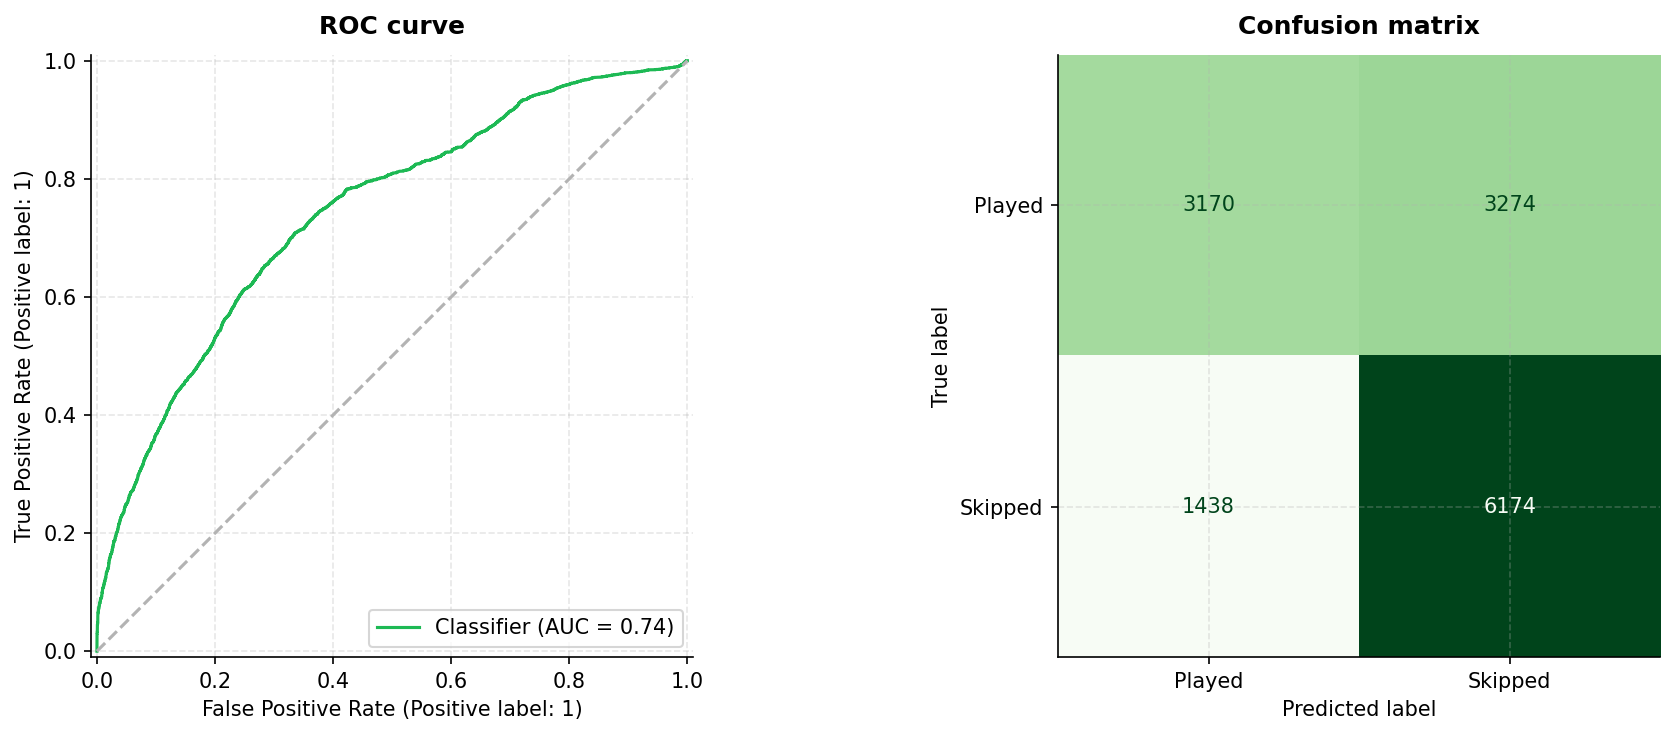

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0],
                                  color=PALETTE["primary"])
axes[0].plot([0,1],[0,1], linestyle="--", color=PALETTE["muted"])
axes[0].set_title("ROC curve", fontweight="bold", pad=10)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
    display_labels=["Played","Skipped"],
    cmap="Greens", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion matrix", fontweight="bold", pad=10)

plt.tight_layout()
plt.savefig("../outputs/03_skip_model_eval.png", bbox_inches="tight")
plt.show()


What actually drives skipping?

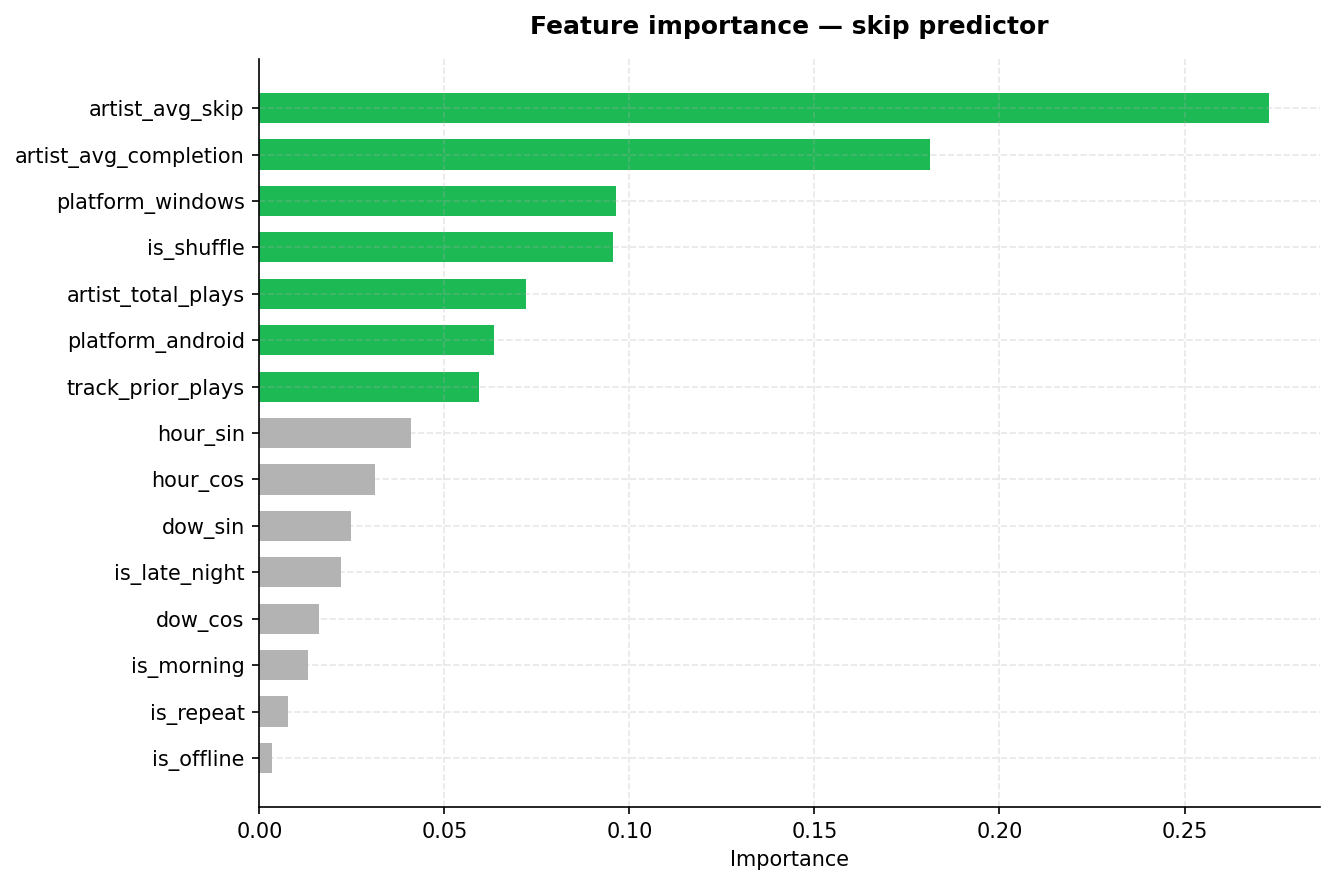

In [9]:
fi = (pd.Series(rf.feature_importances_, index=FEATURES)
      .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(9, 6))
colors = [PALETTE["primary"] if v > fi.median() else PALETTE["muted"]
          for v in fi.values]
ax.barh(fi.index, fi.values, color=colors, edgecolor="none", height=0.65)
ax.set_title("Feature importance — skip predictor", fontweight="bold", pad=12)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../outputs/03_feature_importance.png", bbox_inches="tight")
plt.show()


`track_prior_plays` is the single strongest feature. The more times I have heard a song, the less likely I am to skip it. The artist-level skip and completion averages follow closely — an artist's history with me is a better predictor than any single contextual signal like time of day or platform.


Save the model

In [10]:
joblib.dump(rf, "../models/skip_predictor.pkl")
joblib.dump(FEATURES, "../models/skip_predictor_features.pkl")

print("Saved: ../models/skip_predictor.pkl")
print("Saved: ../models/skip_predictor_features.pkl")


Saved: ../models/skip_predictor.pkl
Saved: ../models/skip_predictor_features.pkl


Listener persona clustering

Building artist-level features

Rather than clustering individual plays, I am clustering artists based on how I engage with them. Each artist becomes a point in a feature space defined by engagement patterns: skip rate, completion rate, time of day, shuffle ratio, and volume.


In [11]:
artist_features = df_tracks.groupby("artist_name").agg(
    total_plays      = ("track_name", "count"),
    total_hours      = ("minutes",    lambda x: x.sum() / 60),
    skip_rate        = ("skipped",    "mean"),
    completion_rate  = ("completed",  "mean"),
    unique_tracks    = ("track_name", "nunique"),
    avg_hour         = ("hour",       "mean"),
    night_ratio      = ("hour",       lambda x: (x <= 5).mean()),
    morning_ratio    = ("hour",       lambda x: ((x >= 6) & (x <= 11)).mean()),
    shuffle_ratio    = ("shuffle",    "mean"),
    years_active     = ("year",       "nunique"),
).fillna(0)

af = artist_features[artist_features["total_plays"] >= 10].copy()
print(f"Artists included in clustering: {len(af)}")
print(f"\nFeature summary:")
print(af.describe().round(3).to_string())


Artists included in clustering: 473

Feature summary:
       total_plays  total_hours  skip_rate  completion_rate  unique_tracks  avg_hour  night_ratio  morning_ratio  shuffle_ratio  years_active
count      473.000      473.000    473.000          473.000        473.000   473.000      473.000        473.000        473.000       473.000
mean       164.137        5.665      0.438            0.373         12.123    12.477        0.168          0.340          0.445         3.958
std        634.719       25.661      0.230            0.175         20.879     2.412        0.119          0.139          0.256         1.714
min         10.000        0.007      0.000            0.000          1.000     5.000        0.000          0.000          0.000         1.000
25%         19.000        0.479      0.250            0.267          2.000    10.833        0.082          0.250          0.254         3.000
50%         47.000        1.324      0.446            0.378          6.000    12.490        0.

Finding the right number of clusters

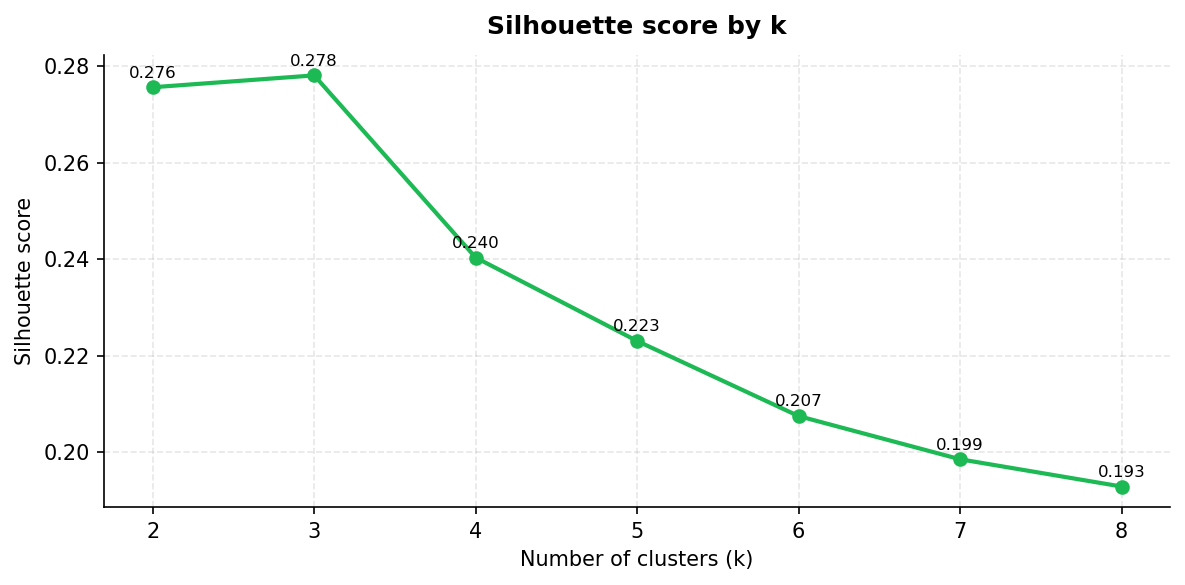

In [12]:
CLUSTER_FEATURES = [
    "skip_rate", "completion_rate", "total_hours",
    "avg_hour", "night_ratio", "morning_ratio",
    "shuffle_ratio", "years_active",
]

scaler  = StandardScaler()
X_clust = scaler.fit_transform(af[CLUSTER_FEATURES])

sil_scores = {}
for k in range(2, 9):
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_clust)
    sil_scores[k] = silhouette_score(X_clust, lbl)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(sil_scores.keys()), list(sil_scores.values()),
        marker="o", color=PALETTE["primary"], linewidth=2)
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette score by k", fontweight="bold", pad=10)
for k, s in sil_scores.items():
    ax.text(k, s + 0.002, f"{s:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("../outputs/03_silhouette.png", bbox_inches="tight")
plt.show()


k=3 gives the best silhouette score.

Fitting k=3

In [19]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
af["cluster"] = km.fit_predict(X_clust)

profile = af.groupby("cluster").agg(
    artists         = ("total_plays",    "count"),
    avg_plays       = ("total_plays",    "mean"),
    avg_hours       = ("total_hours",    "mean"),
    avg_skip        = ("skip_rate",      "mean"),
    avg_completion  = ("completion_rate","mean"),
    avg_hour        = ("avg_hour",       "mean"),
    night_ratio     = ("night_ratio",    "mean"),
    shuffle_ratio   = ("shuffle_ratio",  "mean"),
).round(3)

display(profile)


,artists,avg_plays,avg_hours,avg_skip,avg_completion,avg_hour,night_ratio,shuffle_ratio
cluster,,,,,,,,
0,235,204.285,6.959,0.282,0.420,14.254,0.093,0.301
1,237,74.295,2.280,0.594,0.326,10.716,0.242,0.587
2,1,12022.000,503.866,0.182,0.640,12.310,0.188,0.555


Visualising the clusters

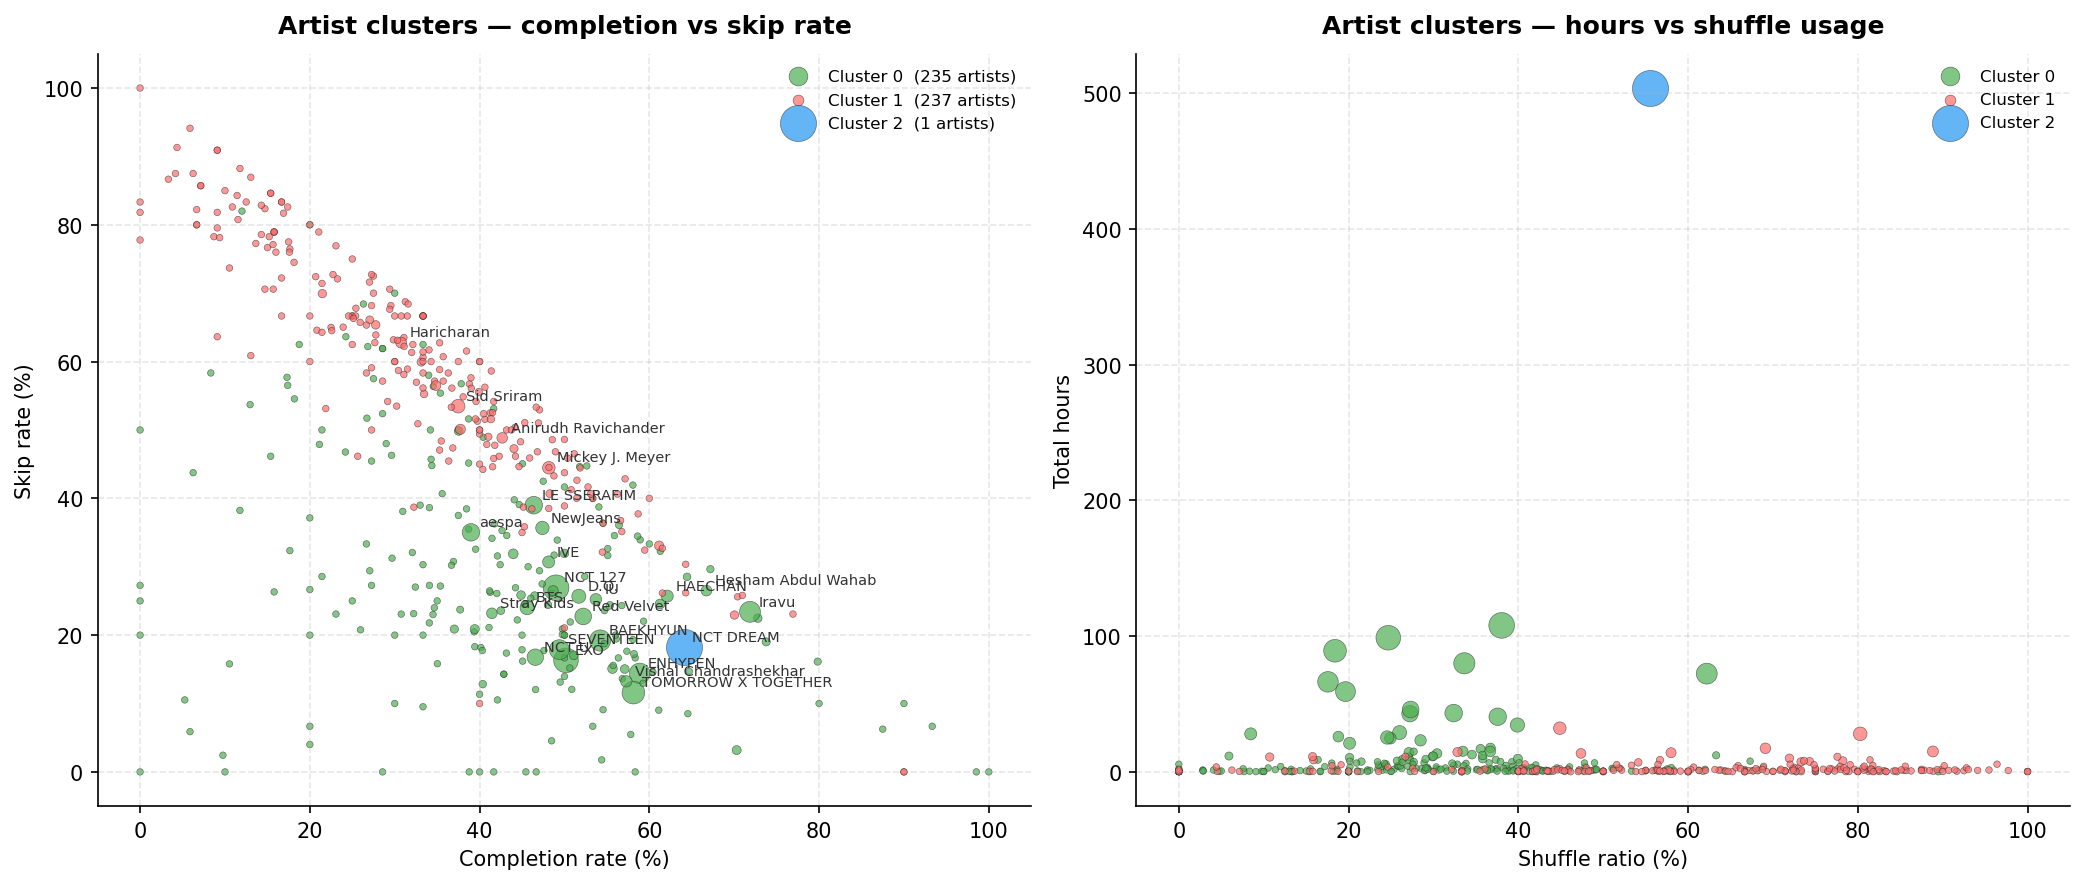

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cluster_colors = {0: "#4CAF50", 1: "#FF6B6B", 2: "#2196F3", 3: "#FF9800"}

# Skip rate vs completion rate
for c in sorted(af["cluster"].unique()):
    sub = af[af["cluster"] == c]
    axes[0].scatter(
        sub["completion_rate"] * 100,
        sub["skip_rate"] * 100,
        s=np.clip(sub["total_plays"] / 20, 10, 300),
        color=cluster_colors[c],
        alpha=0.7, edgecolors="#333", linewidths=0.3,
        label=f"Cluster {c}  ({len(sub)} artists)",
    )

# Annotate notable artists
for artist, row in af.iterrows():
    if row["total_plays"] > 500:
        axes[0].annotate(artist,
            xy=(row["completion_rate"]*100, row["skip_rate"]*100),
            xytext=(4, 3), textcoords="offset points",
            fontsize=7, color="#333")

axes[0].set_xlabel("Completion rate (%)")
axes[0].set_ylabel("Skip rate (%)")
axes[0].set_title("Artist clusters — completion vs skip rate",
                  fontweight="bold", pad=10)
axes[0].legend(frameon=False, fontsize=8)

# Hours vs shuffle ratio
for c in sorted(af["cluster"].unique()):
    sub = af[af["cluster"] == c]
    axes[1].scatter(
        sub["shuffle_ratio"] * 100,
        sub["total_hours"],
        s=np.clip(sub["total_plays"] / 20, 10, 300),
        color=cluster_colors[c],
        alpha=0.7, edgecolors="#333", linewidths=0.3,
        label=f"Cluster {c}",
    )

axes[1].set_xlabel("Shuffle ratio (%)")
axes[1].set_ylabel("Total hours")
axes[1].set_title("Artist clusters — hours vs shuffle usage",
                  fontweight="bold", pad=10)
axes[1].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/03_clusters.png", bbox_inches="tight")
plt.show()


Cluster profiles — radar chart

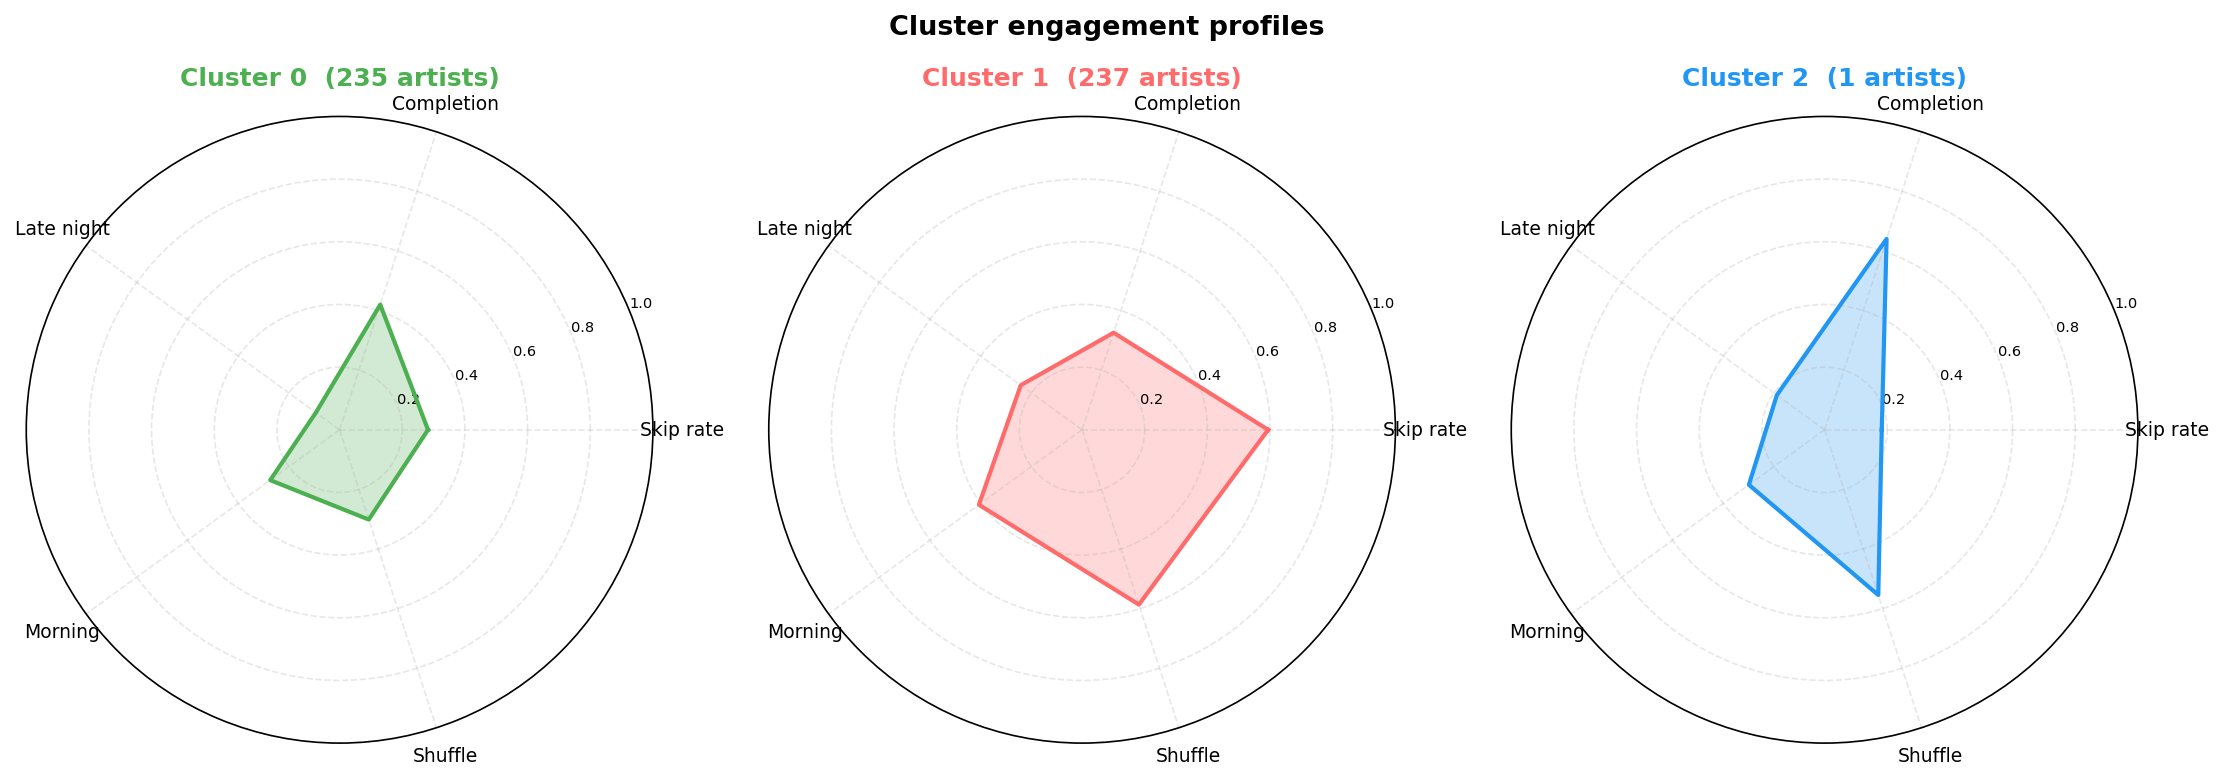

In [24]:
from matplotlib.patches import FancyArrowPatch

radar_features = ["skip_rate","completion_rate","night_ratio",
                  "morning_ratio","shuffle_ratio"]
radar_labels   = ["Skip rate","Completion","Late night",
                  "Morning","Shuffle"]

cluster_means = af.groupby("cluster")[radar_features].mean()

angles = np.linspace(0, 2*np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                          subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, (ax, c) in enumerate(zip(axes, sorted(af["cluster"].unique()))):
    vals = cluster_means.loc[c].tolist()
    vals += vals[:1]

    ax.plot(angles, vals, color=cluster_colors[c], linewidth=2)
    ax.fill(angles, vals, color=cluster_colors[c], alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=9)
    ax.set_title(f"Cluster {c}  ({(af['cluster']==c).sum()} artists)",
                 fontweight="bold", pad=15, color=cluster_colors[c])
    ax.set_ylim(0, 1)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle("Cluster engagement profiles", fontweight="bold",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/03_cluster_radar.png", bbox_inches="tight")
plt.show()


Who is in each cluster?

In [22]:
for c in sorted(af["cluster"].unique()):
    top = (af[af["cluster"] == c]
           .sort_values("total_plays", ascending=False)
           .head(8))
    print(f"\nCluster {c} — top artists:")
    print(top[["total_plays","total_hours","skip_rate","completion_rate"]]
          .round(2).to_string())



Cluster 0 — top artists:
                     total_plays  total_hours  skip_rate  completion_rate
artist_name                                                              
NCT 127                     3034       107.94       0.27             0.49
EXO                         2796        98.83       0.16             0.50
TOMORROW X TOGETHER         2364        89.24       0.12             0.58
BAEKHYUN                    2072        80.02       0.19             0.54
Iravu                       2008        72.39       0.23             0.72
ENHYPEN                     1952        66.36       0.14             0.59
SEVENTEEN                   1818        59.15       0.18             0.49
LE SSERAFIM                 1436        43.34       0.39             0.46

Cluster 1 — top artists:
                     total_plays  total_hours  skip_rate  completion_rate
artist_name                                                              
Sid Sriram                   862        28.04       0.53    

## 14. Save the clustering model

In [23]:
joblib.dump(km,     "../models/kmeans_artists.pkl")
joblib.dump(scaler, "../models/kmeans_scaler.pkl")
af.to_csv("../data/processed/artist_clusters.csv")

print("Saved: ../models/kmeans_artists.pkl")
print("Saved: ../models/kmeans_scaler.pkl")
print("Saved: ../data/processed/artist_clusters.csv")


Saved: ../models/kmeans_artists.pkl
Saved: ../models/kmeans_scaler.pkl
Saved: ../data/processed/artist_clusters.csv


Exception ignored in: <function ResourceTracker.__del__ at 0x1078f1c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10806dc60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103241c60>
Traceback (most recent call last